In [1]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "nova-23.lyon.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

### Experiment 1b

In [ ]:
experiment_50k = {
    'forst(50-100Mo)': {
        'start': dt.datetime(2025, 8, 8, 14, 46, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 14, 56, 0, tzinfo=local_tz)
    },
    'forst(no cache)': {
        'start': dt.datetime(2025, 8, 8, 15, 1, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 15, 11, 0, tzinfo=local_tz)
    }
}
"""
TODO
'forst': {
        'start': dt.datetime(2025, 8, 8, 16, 44, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 16, 54, 0, tzinfo=local_tz)
    },
    'forst(317-10)': {
        'start': dt.datetime(2025, 8, 8, 16, 59, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 17, 9, 0, tzinfo=local_tz)
    },
    'forst(128-1)': {
        'start': dt.datetime(2025, 8, 8, 17, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 17, 23, 0, tzinfo=local_tz)
    }
    
"""
experiment_10k = {
    'forst': {
        'start': dt.datetime(2025, 8, 8, 16, 1, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 16, 11, 0, tzinfo=local_tz)
    },
    'forst(317-10)': {
        'start': dt.datetime(2025, 8, 8, 16, 16, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 16, 26, 30, tzinfo=local_tz)
    },
    'forst(128-1)': {
        'start': dt.datetime(2025, 8, 8, 16, 31, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 16, 41, 30, tzinfo=local_tz)
    },
    'forst(50-100Mo)': {
        'start': dt.datetime(2025, 8, 8, 16, 46, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 16, 56, 30, tzinfo=local_tz)
    },
    'forst(no cache)': {
        'start': dt.datetime(2025, 8, 8, 17, 2, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 17, 12, 30, tzinfo=local_tz)
    }
}

experiment_1k = {
    'forst': {
        'start': dt.datetime(2025, 8, 8, 14, 17, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 14, 24, 0, tzinfo=local_tz)
    },
    'forst(317-10)': {
        'start': dt.datetime(2025, 8, 8, 14, 31, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 14, 41, 0, tzinfo=local_tz)
    },
    'forst(128-1)': {
        'start': dt.datetime(2025, 8, 8, 15, 16, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 15, 26, 0, tzinfo=local_tz)
    },
    'forst(50-100Mo)': {
        'start': dt.datetime(2025, 8, 8, 14, 46, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 14, 56, 0, tzinfo=local_tz)
    },
    'forst(no cache)': {
        'start': dt.datetime(2025, 8, 8, 15, 1, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 8, 15, 11, 0, tzinfo=local_tz)
    }
}

### TPUT Measurement

In [ ]:
metric_query = 'sum(rate(flink_taskmanager_job_task_operator_numRecordsOut{operator_name=~"Source:.*"}[1m]))'
step = "5s"
output_filename = 'xp1bresults/50ktputb/exp1b_50k_tput.csv'
execute_query_range(experiment_50k, metric_query, step, output_filename)

metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'xp1bresults/50ktputb/exp1b_50k_cpu_load.csv'
execute_query_range(experiment_50k, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'xp1bresults/50ktputb/exp1b_50k_cp_time.csv'
execute_query_range(experiment_50k, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointSize{component="jobmanager"}'
step = "30s"
output_filename = 'xp1bresults/50ktputb/exp1b_50k_cp_size.csv'
execute_query_range(experiment_50k, metric_query, step, output_filename)

metric_query = 'sum(flink_taskmanager_job_task_operator_column_family_rocksdb_total_sst_files_size{component="taskmanager"})'
step = "5s"
output_filename = 'xp1bresults/50ktputb/exp1b_50k_sst_size.csv'
execute_query_range(experiment_50k, metric_query, step, output_filename)

metric_query = 'sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m]))/(sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_miss{component="taskmanager"}[2m]))+sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m])))'
step = "5s"
output_filename = 'xp1bresults/50ktputb/exp1b_50k_hit_ratio.csv'
execute_query_range(experiment_50k, metric_query, step, output_filename)

metric_query = 'sum(minio_node_drive_used_bytes{job=~"minio"})'
step = "1m"
output_filename = 'xp1bresults/50ktputb/exp1b_50k_drive_used_bytes.csv'
execute_query_range(experiment_50k, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1bresults/50ktput/exp1b_50k_tput.csv'

Beginning request execution

File saved : 'xp1bresults/50ktput/exp1b_50k_cpu_load.csv'

Beginning request execution

File saved : 'xp1bresults/50ktput/exp1b_50k_cp_time.csv'

Beginning request execution

File saved : 'xp1bresults/50ktput/exp1b_50k_cp_size.csv'

Beginning request execution

File saved : 'xp1bresults/50ktput/exp1b_50k_sst_size.csv'

Beginning request execution

File saved : 'xp1bresults/50ktput/exp1b_50k_hit_ratio.csv'

Beginning request execution

File saved : 'xp1bresults/50ktput/exp1b_50k_drive_used_bytes.csv'


### Boxplot from file

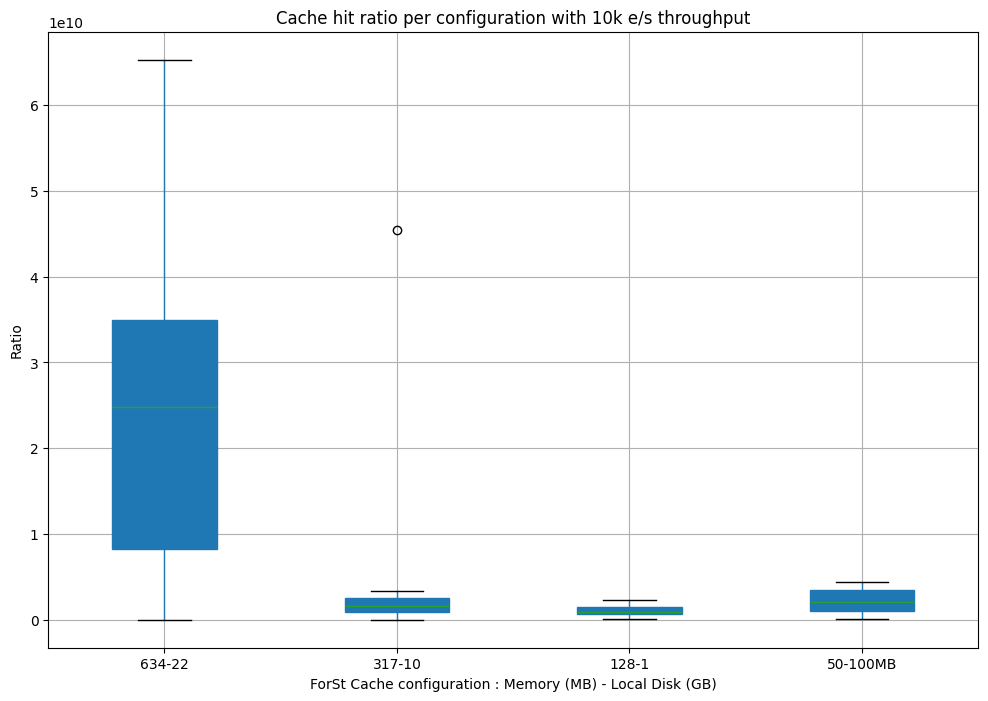

In [3]:
file_path = 'xp1bresults/50ktput/exp1b_50k_drive_used_bytes.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['634-22', '317-10', '128-1', '50-100MB', 'no cache']
    df = df.iloc[:, :-1] 

    plt.figure(figsize=(12, 8))
    df.boxplot(grid=True, patch_artist=True)
    #df.plot(grid=True, ax=plt.gca()) #style='o'

    plt.title('Cache hit ratio per configuration with 10k e/s throughput')
    plt.ylabel('Ratio')
    plt.xlabel('ForSt Cache configuration : Memory (MB) - Local Disk (GB)')
    #plt.xticks([])

    #plt.yticks(np.arange(0, 1.2, 0.2))
    plt.savefig('xp1bresults/50ktput/exp1b_50k_drive_used_bytes.png')
    
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


files_50k = {'xp1results/50ktput/exp1a_50k_cp_time.csv': '50k TPUT'}
files_10k = {'xp1results/10ktput/exp1a_10k_cp_time.csv': '10k TPUT'}
files_maxtput = {'xp1results/maxtput/exp1a_maxtput_cp_time.csv': 'Max TPUT'}

def load_and_prepare_data(file_dict):
    """Charge un fichier CSV et prépare les données pour le boxplot."""
    file_path = list(file_dict.keys())[0]
    try:
        df = pd.read_csv(file_path, index_col=0)
        df.columns = [col.split('{')[0].split('_')[-1] if '{' in col else col for col in df.columns]
        df.columns = ['rocks', 'forst', 'forst_no_cache']
        return df
    except FileNotFoundError:
        print(f"Erreur : Le fichier {file_path} est introuvable.")
        return None

df_50k = load_and_prepare_data(files_50k)
df_10k = load_and_prepare_data(files_10k)
df_maxtput = load_and_prepare_data(files_maxtput)

if df_50k is not None and df_10k is not None and df_maxtput is not None:
    labels = ['rocks', 'forst', 'forst_no_cache']
    data_50k = [df_50k[col].dropna() for col in labels]
    data_10k = [df_10k[col].dropna() for col in labels]
    data_maxtput = [df_maxtput[col].dropna() for col in labels]

    plt.figure(figsize=(16, 9))
    fig, ax = plt.subplots(figsize=(16, 9))

    x_positions = np.arange(len(labels))
    width = 0.25 

    bplot1 = ax.boxplot(data_maxtput, 
                        positions=x_positions - width, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="cornflowerblue"))

    bplot2 = ax.boxplot(data_50k, 
                        positions=x_positions, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="tomato"))

    bplot3 = ax.boxplot(data_10k, 
                        positions=x_positions + width, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="lightgreen"))

    ax.set_ylabel('CP Time (ms)')
    ax.set_title('Comparison of Checkpointing time per configuration and throughput')
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Configuration')

    ax.yaxis.grid(True, linestyle='--')

    legend_50k = mpatches.Patch(color='cornflowerblue', label='Max TPUT')
    legend_10k = mpatches.Patch(color='tomato', label='50k TPUT')
    legend_maxtput = mpatches.Patch(color='lightgreen', label='10k TPUT')
    ax.legend(handles=[legend_50k, legend_10k, legend_maxtput])

    fig.tight_layout()
    plt.savefig('xp1results/boxplot_cp_time_comparison.png', dpi=300)
    plt.show()

Erreur : Le fichier xp1results/50ktput/exp1a_50k_cp_time.csv est introuvable.
Erreur : Le fichier xp1results/10ktput/exp1a_10k_cp_time.csv est introuvable.
Erreur : Le fichier xp1results/maxtput/exp1a_maxtput_cp_time.csv est introuvable.


Le graphique avec la légende personnalisée a été sauvegardé sous 'exp1b_drive_usage_stacked_area_custom_legend.png'


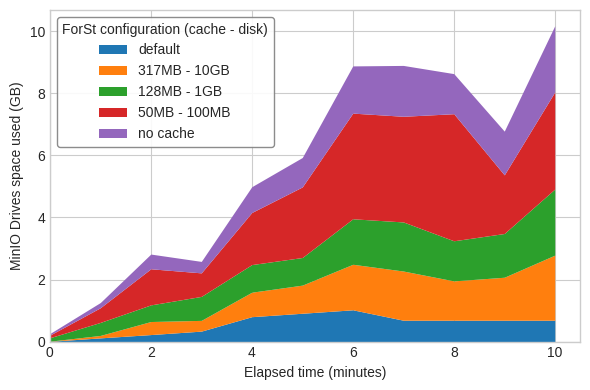

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_relative_time_stacked_area(csv_file):
    """
    Charge un fichier CSV avec plusieurs séries temporelles, les aligne
    sur un axe de temps relatif (delta) et génère un graphique en aires empilées.
    """
    try:
        # 1. Charger les données et parser la colonne de temps
        df = pd.read_csv(csv_file)
        df['Time'] = pd.to_datetime(df['Time'])

        processed_series = {}
        data_columns = df.columns[1:]

        # 2. Traiter chaque colonne comme une expérience séparée
        for col_name in data_columns:
            series_df = df[['Time', col_name]].dropna().copy()
            
            if not series_df.empty:
                start_time = series_df['Time'].iloc[0]
                series_df['Elapsed_Minutes'] = (series_df['Time'] - start_time).dt.total_seconds() / 60
                
                bytes_to_gb = 1024**3
                # Le nom de la colonne est temporaire, il sera remplacé plus tard
                series = series_df.set_index('Elapsed_Minutes')[col_name] / bytes_to_gb
                processed_series[col_name] = series

        if not processed_series:
            print("Aucune donnée valide trouvée dans le fichier.")
            return

        combined_df = pd.concat(processed_series.values(), axis=1)
        
        combined_df.ffill(inplace=True)
        combined_df.fillna(0, inplace=True)
        #combined_df = combined_df.iloc[:, :-1]
        # --- MODIFICATION 1 : Définir les nouvelles étiquettes pour la légende ---
        new_labels = ["default", "317MB - 10GB", "128MB - 1GB", "50MB - 100MB", "no cache"]

        # Assigner les nouvelles étiquettes comme noms de colonnes au DataFrame
        # Cela mettra automatiquement à jour les entrées de la légende
        if len(new_labels) == len(combined_df.columns):
            combined_df.columns = new_labels
        else:
            print("Attention : Le nombre de labels fournis ne correspond pas au nombre de séries de données trouvées.")

        # 3. Créer le graphique en aires empilées
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(6, 4))
        
        combined_df.plot.area(ax=ax, stacked=True, linewidth=0)

        ax.set_xlabel("Elapsed time (minutes)")
        ax.set_ylabel("MinIO Drives space used (GB)")
        ax.legend(
            title='ForSt configuration (cache - disk)',
            loc='upper left',
            # --- Voici les options pour le cadre ---
            frameon=True,             # DESSINER LE CADRE (True/False)
            edgecolor='gray',         # COULEUR DE LA BORDURE
            facecolor='white',        # Couleur de fond
            framealpha=0.9            # Transparence du fond
        )
        
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

        plt.tight_layout()
        plt.savefig('exp1b_drive_usage_stacked_area.png')
        print("Le graphique avec la légende personnalisée a été sauvegardé sous 'exp1b_drive_usage_stacked_area_custom_legend.png'")
        plt.show()

    except FileNotFoundError:
        print(f"Erreur : Le fichier '{csv_file}' est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")

# --- Lancement du script ---
plot_relative_time_stacked_area('exp1b_1k_drive_used_bytes.csv')

Le graphique a été sauvegardé sous 'checkpoint_duration_comparison_10k_last_removed.png'


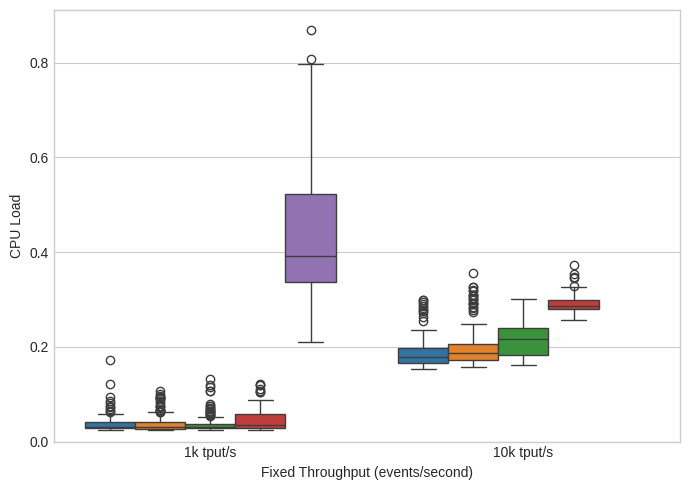

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def process_checkpoint_file(filename, experiment_label, config_labels):
    """
    Charge et transforme un fichier de temps de checkpoint pour le rendre
    utilisable par seaborn pour un boxplot groupé.
    Cette version lit uniquement les colonnes nécessaires.
    """
    # Déterminer le nombre de colonnes à lire : 'Time' + le nombre de configs
    cols_to_read = len(config_labels) + 1
    
    # Définir les noms pour les colonnes lues
    col_names = ['Time'] + config_labels
    
    # Lire le CSV en ignorant l'en-tête, en ne lisant que les colonnes utiles
    # et en appliquant directement les bons noms
    df = pd.read_csv(filename, skiprows=1, usecols=range(cols_to_read), names=col_names)
    
    # Pivoter le DataFrame du format "large" au format "long"
    melted_df = df.melt(id_vars=['Time'], 
                        value_vars=config_labels, 
                        var_name='Configuration', 
                        value_name='Checkpoint Size (Bytes)')
    
    # Supprimer les lignes vides et ajouter le label de l'expérience
    melted_df.dropna(subset=['Checkpoint Size (Bytes)'], inplace=True)
    melted_df['Experiment'] = experiment_label
    
    return melted_df

# --- Script principal ---

# 1. Définir les configurations pour chaque fichier.
#    Pour le fichier '10k', on omet simplement le dernier label.
config_1k = ["default", "317MB - 10GB", "128MB - 1GB", "50MB - 100MB", "no cache"]
config_10k = ["default", "317MB - 10GB", "128MB - 1GB", "50MB - 100MB"] # "no cache" est retiré

# 2. Définir une liste de tâches à traiter
files_to_process = [
    {'filename': '1ktput/exp1b_1k_cpu_load.csv', 'label': '1k tput/s', 'configs': config_1k},
    {'filename': '10ktput/exp1b_10k_cpu_load.csv', 'label': '10k tput/s', 'configs': config_10k}
]

# 3. Traiter chaque fichier et combiner les résultats
all_data = []
for task in files_to_process:
    try:
        processed_df = process_checkpoint_file(task['filename'], task['label'], task['configs'])
        all_data.append(processed_df)
    except FileNotFoundError:
        print(f"Attention : Le fichier {task['filename']} est introuvable.")

if not all_data:
    print("Aucun fichier n'a pu être traité. Arrêt du script.")
else:
    combined_df = pd.concat(all_data, ignore_index=True)

    # 4. Créer le boxplot groupé
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(7, 5))

    sns.boxplot(
        x='Experiment',
        y='Checkpoint Size (Bytes)',
        hue='Configuration',
        data=combined_df,
        ax=ax,
        legend=False
    )
 
    ax.set_xlabel('Fixed Throughput (events/second)')
    ax.set_ylabel('CPU Load')
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig('cpu_load_comparison_10k_last_removed.svg')
    print("Le graphique a été sauvegardé sous 'checkpoint_duration_comparison_10k_last_removed.png'")